In [1]:
# Authors: The scikit-learn developers
# SPDX-License-Identifier: BSD-3-Clause
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np

In [2]:
data = pd.read_csv("Advertising_TV_sales.csv")

In [3]:
data.head()
data = data.drop(columns=['Unnamed: 0'])

In [4]:
X = data[['TV']]
Y = data['sales']

In [5]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [6]:
# ----------------------------------
# Train linear regression models
# ----------------------------------
model_y = LinearRegression()

model_y.fit(X, Y)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [7]:
print("Y model: Y =", model_y.coef_[0], "* X +", model_y.intercept_)

Y model: Y = 0.04753664043301975 * X + 7.032593549127695


In [8]:
lets_predict_sales = model_y.predict([[1000]])

/home/govardhanks/test/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [9]:
print(lets_predict_sales)

[54.56923398]


In [10]:
# Create X range for regression line
x_range = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)

# Predict Y values for regression line
y_pred_line = model_y.predict(x_range)

# New prediction point
new_x_value = 1000
predicted_y = model_y.predict([[new_x_value]])


/home/govardhanks/test/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/home/govardhanks/test/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


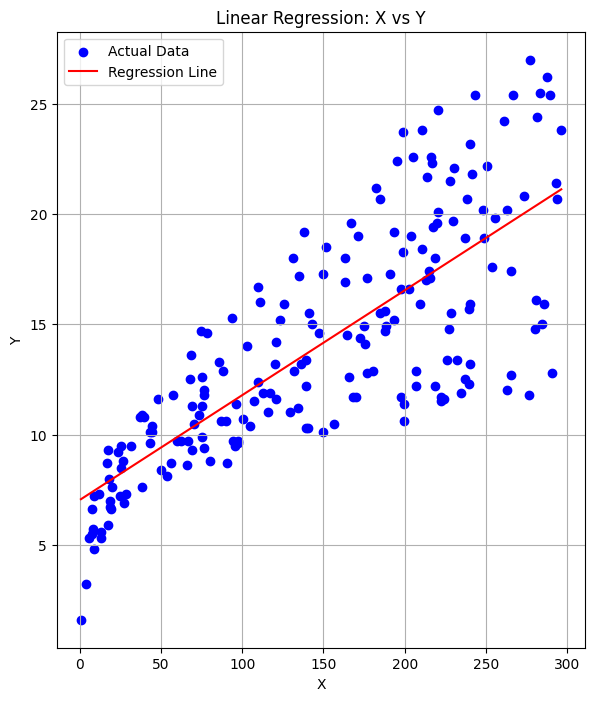

In [11]:
# ----------------------------------
# Plot 1: X vs Y
# ----------------------------------
plt.figure(figsize=(15, 8))

plt.subplot(1, 2, 1)
plt.scatter(X, Y, color='blue', label='Actual Data')
plt.plot(x_range, y_pred_line, color='red', label='Regression Line')
#plt.scatter(new_x_value, predicted_y, color='green', s=100, label='Predicted Point')
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Linear Regression: X vs Y")
plt.legend()
plt.grid(True)

In [12]:
m = model_y.coef_[0]        # slope
c = model_y.intercept_     # intercept
r2 = model_y.score(X, Y)   # R-squared

In [13]:
equation_text = f"y = {m:.2f}x + {c:.2f}\n$R^2$ = {r2:.3f}"

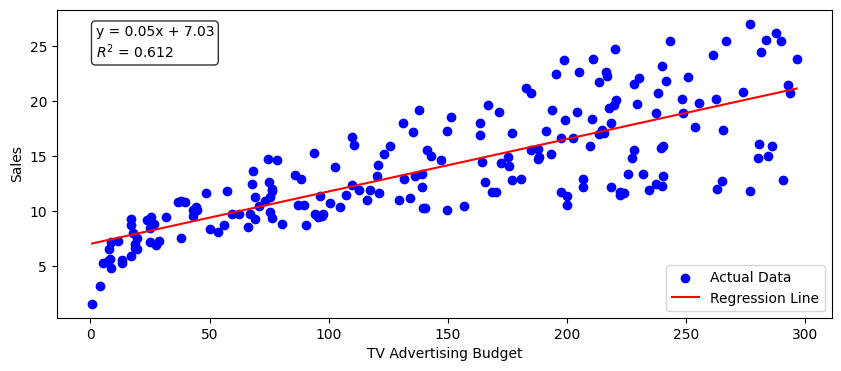

In [14]:

# Plot
plt.figure(figsize=(10, 4))

plt.scatter(X, Y, color='blue', label='Actual Data')
plt.plot(x_range, y_pred_line, color='red', label='Regression Line')
#plt.scatter(new_x_value, predicted_y, color='green', s=100, label='Predicted Point')

# Add equation text
plt.text(
    0.05, 0.95,
    equation_text,
    transform=plt.gca().transAxes,
    fontsize=10,
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)

plt.xlabel("TV Advertising Budget")
plt.ylabel("Sales")
plt.legend()
plt.show()

In [15]:
# ================== PDF REGRESSION REPORT ==================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from reportlab.platypus import (
    SimpleDocTemplate, Paragraph, Spacer, Table, TableStyle, Image
)
from reportlab.lib.pagesizes import A4
from reportlab.lib.styles import getSampleStyleSheet
from reportlab.lib import colors
from scipy import stats

# ------------------ BASIC OBJECTS ------------------
X = data[['TV']]
Y = data['sales']
n = len(Y)

# ------------------ DESCRIPTIVE STATS ------------------
tv_mean, sales_mean = X.TV.mean(), Y.mean()
tv_median, sales_median = X.TV.median(), Y.median()
tv_mode, sales_mode = X.TV.mode()[0], Y.mode()[0]
tv_std, sales_std = X.TV.std(), Y.std()

# ------------------ REGRESSION STATS ------------------
slope = model_y.coef_[0]
intercept = model_y.intercept_

y_pred = model_y.predict(X)
residuals = Y - y_pred

RSS = np.sum(residuals**2)
TSS = np.sum((Y - sales_mean)**2)
R2 = 1 - RSS / TSS
R = np.sqrt(R2)

RSE = np.sqrt(RSS / (n - 2))

Sxx = np.sum((X.TV - tv_mean)**2)
SE_slope = RSE / np.sqrt(Sxx)
SE_intercept = RSE * np.sqrt((1/n) + (tv_mean**2 / Sxx))

t_slope = slope / SE_slope
p_slope = 2 * (1 - stats.t.cdf(abs(t_slope), df=n-2))

t_intercept = intercept / SE_intercept
p_intercept = 2 * (1 - stats.t.cdf(abs(t_intercept), df=n-2))

t_crit = stats.t.ppf(0.975, df=n-2)
ci_lower = slope - t_crit * SE_slope
ci_upper = slope + t_crit * SE_slope

# ------------------ PLOT ------------------
x_range = np.linspace(X.TV.min(), X.TV.max(), 100).reshape(-1,1)
y_line = model_y.predict(x_range)

plt.figure(figsize=(6,4))
plt.scatter(X, Y, label="Actual Data")
plt.plot(x_range, y_line, color="red", label="Regression Line")

eq_text = f"y = {slope:.4f}x + {intercept:.2f}\n$R^2$ = {R2:.3f}"
plt.text(0.05, 0.95, eq_text, transform=plt.gca().transAxes,
         bbox=dict(facecolor="white", alpha=0.8), va="top")

plt.xlabel("TV Budget")
plt.ylabel("Sales")
plt.legend()
plt.tight_layout()
plot_file = "regression_plot.png"
plt.savefig(plot_file)
plt.close()

# ------------------ PDF ------------------
pdf_file = "TV_Advertising_Regression_Report.pdf"
doc = SimpleDocTemplate(pdf_file, pagesize=A4)
styles = getSampleStyleSheet()
elements = []

elements.append(Paragraph("TV Advertising vs Sales – Linear Regression Report", styles["Title"]))
elements.append(Spacer(1, 12))

elements.append(Paragraph(
    "This report analyses the relationship between TV advertising budget and sales "
    "using simple linear regression and formal statistical inference.", styles["Normal"]
))
elements.append(Spacer(1, 12))

# ---- Data head ----
elements.append(Paragraph("First Five Rows of the Dataset", styles["Heading2"]))
table_data = [data.columns.tolist()] + data.head().values.tolist()
tbl = Table(table_data)
tbl.setStyle(TableStyle([
    ("BACKGROUND", (0,0), (-1,0), colors.lightgrey),
    ("GRID", (0,0), (-1,-1), 1, colors.black)
]))
elements.append(tbl)
elements.append(Spacer(1, 14))

# ---- Stats ----
stats_block = f"""
<b>Descriptive Statistics</b><br/>
TV Mean: {tv_mean:.4f}, Median: {tv_median:.4f}, Mode: {tv_mode:.4f}, SD: {tv_std:.4f}<br/>
Sales Mean: {sales_mean:.4f}, Median: {sales_median:.4f}, Mode: {sales_mode:.4f}, SD: {sales_std:.4f}<br/><br/>

<b>Regression Results</b><br/>
Slope = {slope:.6f}<br/>
Intercept = {intercept:.6f}<br/>
RSS = {RSS:.4f}<br/>
RSE = {RSE:.4f}<br/>
R = {R:.4f}<br/>
R² = {R2:.4f}<br/><br/>

<b>T‑Tests (Two‑Tailed)</b><br/>
Slope: t = {t_slope:.4f}, p &lt; 0.001<br/>
Intercept: t = {t_intercept:.4f}, p &lt; 0.001<br/><br/>

<b>95% Confidence Interval for Slope</b><br/>
[{ci_lower:.6f}, {ci_upper:.6f}]<br/><br/>

<b>Interpretation</b><br/>
You can be 95% confident that for every $1000 spent on TV advertising, sales increase between
{ci_lower*1000:.0f} and {ci_upper*1000:.0f} units.
"""

elements.append(Paragraph(stats_block, styles["Normal"]))
elements.append(Spacer(1, 12))

elements.append(Paragraph("Regression Plot", styles["Heading2"]))
elements.append(Image(plot_file, width=420, height=260))

doc.build(elements)

pdf_file

/home/govardhanks/test/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


'TV_Advertising_Regression_Report.pdf'